# What to Do When My Cartogram Didn't Converge

After running `morph_gdf()`, you may see a status of `STALLED` or `COMPLETED` instead of `CONVERGED`. This guide shows you how to diagnose the problem and apply the right fix.

## What the status values mean

| Status | Meaning |
|--------|---------|
| `CONVERGED` | Area errors are within the tolerances you set — done. |
| `COMPLETED` | All iterations were used up but tolerances weren't met. |
| `STALLED` | Error stopped improving (or got worse) — further iterations won't help. |

In [1]:
import matplotlib.pyplot as plt

import carto_flow.data as examples
import carto_flow.flow_cartogram as flow

In [2]:
gdf = examples.load_us_census(population=True)

# Run with fewer iterations to simulate an incomplete result
cartogram = flow.morph_gdf(gdf, "Population", options=flow.MorphOptions(n_iter=20))
print("Status:", cartogram.status)

Morph geometries: 100%|█████████████████| 20/20 [00:02<00:00,  7.88it/s, max=5746.3%, mean=134.2% - completed]

Status: completed


## Step 1: Read the error metrics

`get_errors()` returns the area error for each region. `mean_error_pct` is the average percentage by which regions miss their target area. A result is practically usable when `mean_error_pct` is below ~2–5%.

In [3]:
errors = cartogram.get_errors()
print(f"Mean error:  {errors.mean_error_pct:.1f}%")
print(f"Max error:   {errors.max_error_pct:.1f}%")

Mean error:  134.2%
Max error:   5746.3%


## Step 2: Plot the convergence curve

The convergence plot shows how errors evolved over iterations. A steadily decreasing curve means more iterations will help (`COMPLETED`). A flat or rising curve means the algorithm stalled (`STALLED`) and you need a different approach.

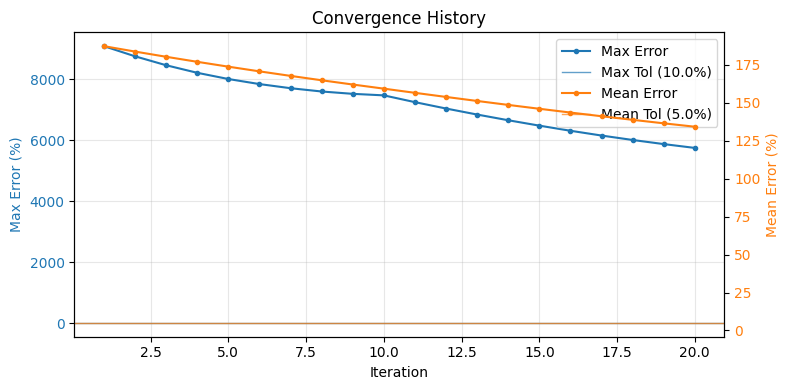

In [4]:
from carto_flow.flow_cartogram.visualization import plot_convergence

fig, ax = plt.subplots(figsize=(8, 4))
plot_convergence(cartogram, ax=ax)
plt.tight_layout();

## Step 3: Fix — iterative refinement with CartogramWorkflow

If the curve is still decreasing, use `CartogramWorkflow` to run additional passes with progressively tighter tolerances. Each call to `morph()` continues from where the last left off.

In [5]:
workflow = flow.CartogramWorkflow(gdf, "Population")

# First pass: fast, loose tolerance
result1 = workflow.morph(options=flow.MorphOptions.preset_balanced())
print(f"After pass 1 — status: {result1.status}, mean error: {result1.get_errors().mean_error_pct:.1f}%")

# Second pass: tighter tolerance, more iterations
result2 = workflow.morph(mean_tol=0.01, max_tol=0.03, n_iter=300)
print(f"After pass 2 — status: {result2.status}, mean error: {result2.get_errors().mean_error_pct:.1f}%")

Morph geometries: 100%|███████████████| 100/100 [00:00<00:00, -134.48it/s, max=135.5%, mean=11.1% - completed]


After pass 1 — status: completed, mean error: 11.1%


Morph geometries:   4%|▊                    | 12/300 [00:00<00:06, 46.82it/s, max=1.7%, mean=0.2% - converged]

After pass 2 — status: converged, mean error: 0.2%


## Alternative fix — multi-resolution morphing

For complex or highly irregular geometries, `morph_multiresolution()` starts at a coarse grid and refines progressively. This often converges where a single-resolution run stalls.

In [6]:
result_mr = flow.multiresolution_morph(gdf, "Population", resolution=256, levels=3)
print(f"Multi-resolution — status: {result_mr.status}, mean error: {result_mr.get_errors().mean_error_pct:.1f}%")

Refining with 256x180 grid:   3%|▎          | 14/500 [00:00<00:09, 51.72it/s, max=3.9%, mean=0.2% - converged]

Multi-resolution — status: converged, mean error: 0.2%


CartogramPlotResult(ax=<Axes: title={'center': 'Cartogram Result'}>, collections=[<matplotlib.collections.PatchCollection object at 0x7f7fe85b4b30>])

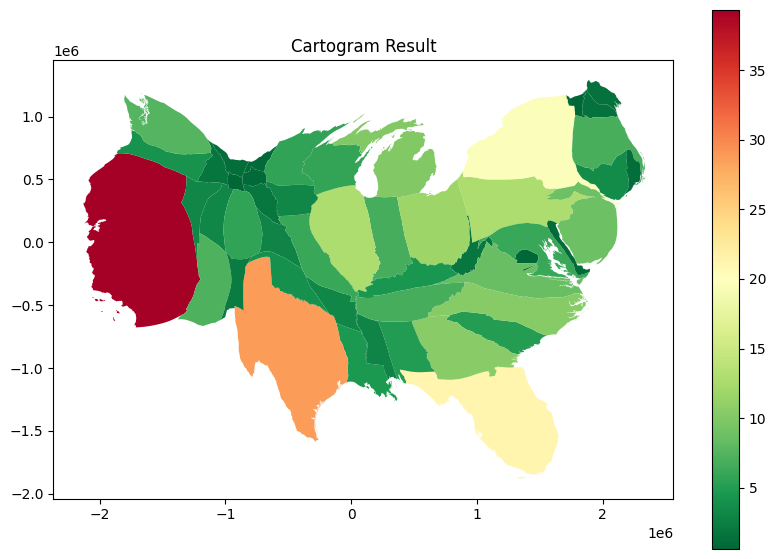

In [9]:
result_mr.plot("Population (Millions)")